## Review 평점과 Sales 히트맵/히스토그램 - Top Collection version

### 히스트그램만 표시 - Y축을 동일한 스케일로

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Data Load

In [6]:
#data = pd.read_csv("review-vc_sales-by_collection_category_20250508_v2.csv")
data = pd.read_csv("review-vc_sales_by_collection.csv")

In [7]:
data

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
0,202201,Box Springs,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0


In [8]:
data1 = data[data['collection'] != '__TOTAL__'].copy()

In [9]:
data1

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0
5,202201,Box Springs,Victor 7.5in,4.750000,1.0,12.0,0.083333,NaN,NaN,NaN,NaN,57457.99,295.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0


In [10]:
data1['collection'].nunique()

669

In [11]:
data1.groupby('financial_category')['collection'].nunique().reset_index()

,financial_category,collection
0,Box Springs,39
1,Foam Mattresses,103
2,Non Bedroom Furniture,82
3,Other Frames & Beds,40
4,Others,20
5,Platform Beds,216
6,SmartBases,22
7,Sofa,28
8,Spring Mattresses,75
9,Toppers,50


In [12]:
#data['yr_month'] = pd.to_datetime(data['yr_month'], format='%Y%m')

In [13]:
mattress_categories = ["Foam Mattresses","Spring Mattresses"]
data1["category_type"] = data1["financial_category"].apply(lambda x: "Mattress" if x in mattress_categories else "Non-Mattress")

In [14]:
data1

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,category_type
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0,Non-Mattress
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0,Non-Mattress
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0,Non-Mattress
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0,Non-Mattress
5,202201,Box Springs,Victor 7.5in,4.750000,1.0,12.0,0.083333,NaN,NaN,NaN,NaN,57457.99,295.0,Non-Mattress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0,Non-Mattress
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0,Non-Mattress
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,Non-Mattress
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0,Non-Mattress


## 1. 상관계수 히트맵

In [16]:
categories = data1['financial_category'].unique()

In [17]:
categories

array(['Box Springs', 'Foam Mattresses', 'Non Bedroom Furniture',
       'Other Frames & Beds', 'Others', 'Platform Beds', 'SmartBases',
       'Sofa', 'Spring Mattresses', 'Toppers'], dtype=object)

In [18]:
# 수치형 컬럼만 선택
#numeric_cols = ['all_avg_rating', 'all_all_cnt', 'written_12_ratio', 'sales_amount']
#numeric_cols = ['written_avg_rating', 'written_12_cnt', 'witten_all_cnt', 'written_12_ratio', 'sales_amount']

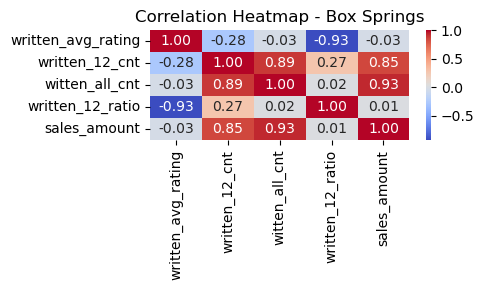

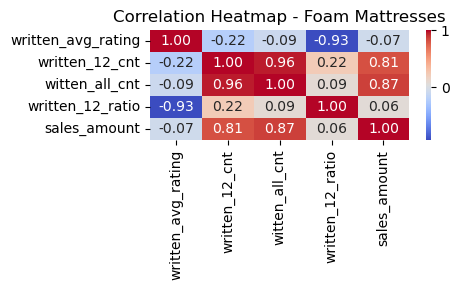

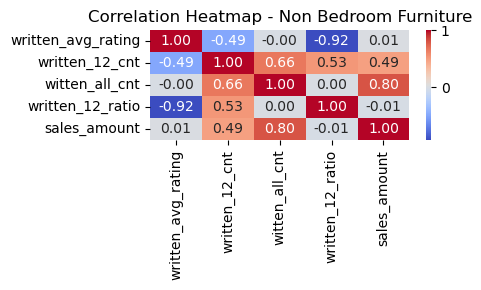

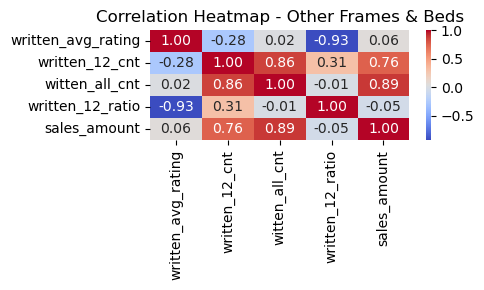

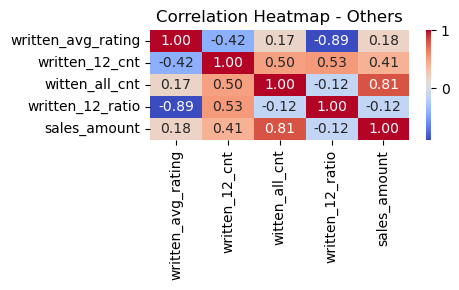

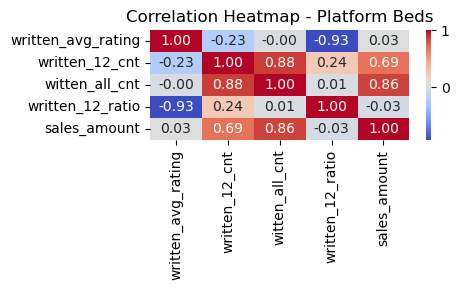

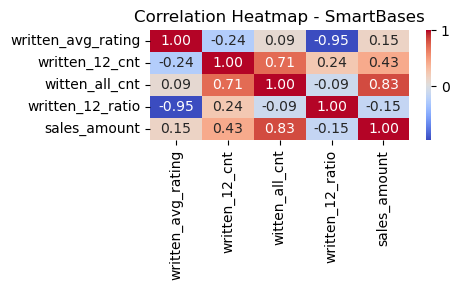

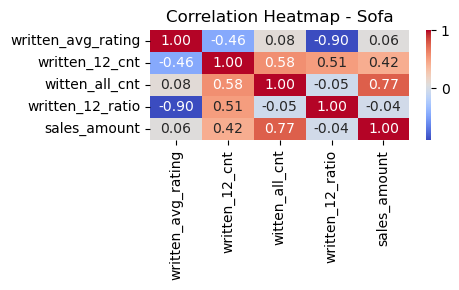

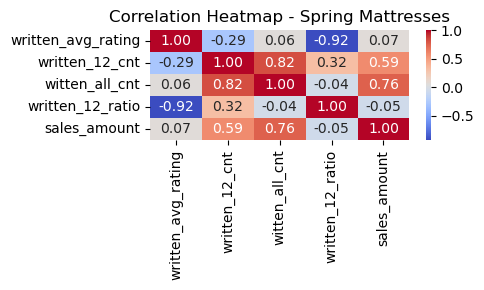

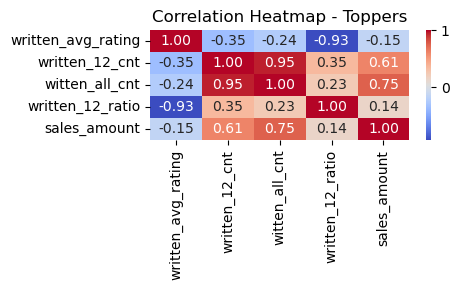

In [19]:
# 카테고리별 히트맵 생성
for category in categories:
    subset = data1[data1['financial_category']==category]

    # 수치형 컬럼만 선택
    #numeric_cols = ['all_avg_rating', 'all_all_cnt', 'written_12_ratio', 'sales_amount']
    numeric_cols = ['written_avg_rating', 'written_12_cnt', 'witten_all_cnt', 'written_12_ratio', 'sales_amount']

    # 상관계수 계산
    corr = subset[numeric_cols].corr()

    # 히트맵 시각화
    plt.figure(figsize=(5, 3))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Correlation Heatmap - {category}")
    plt.tight_layout()
    plt.show()

In [20]:
corr

,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,sales_amount
written_avg_rating,1.000000,-0.353527,-0.242616,-0.928873,-0.145678
written_12_cnt,-0.353527,1.000000,0.950550,0.350983,0.614311
witten_all_cnt,-0.242616,0.950550,1.000000,0.232357,0.752003
written_12_ratio,-0.928873,0.350983,0.232357,1.000000,0.141793
sales_amount,-0.145678,0.614311,0.752003,0.141793,1.000000


## 2. Collection별 산점도 

In [22]:
collection_summary = (data1.groupby(['financial_category','collection']).agg(avg_rating=('written_avg_rating','mean'), total_sales_amt=('sales_amount','sum')).dropna())

In [23]:
collection_summary

avg_rating  total_sales_amt
financial_category collection                                       
Box Springs        5in OOT Box Spring      3.123065        212189.73
                   9in OOT Box Spring      3.623485        250590.40
                   Annemarie               4.257992       8114259.42
                   Armita 5in              3.838275      17228795.75
                   Armita 7in              3.494443      10717131.34
...                                             ...              ...
Toppers            4in MGT w WonderBox     4.066667        100372.36
                   4in MyGel               3.701047        854683.01
                   4in PRMF w Cover        5.000000             0.00
                   4in SWFT w WonderBox    2.791667        168236.40
                   4in Swirl Gel           3.681159        442631.27

[502 rows x 2 columns]

<Axes: xlabel='avg_rating', ylabel='total_sales_amt'>

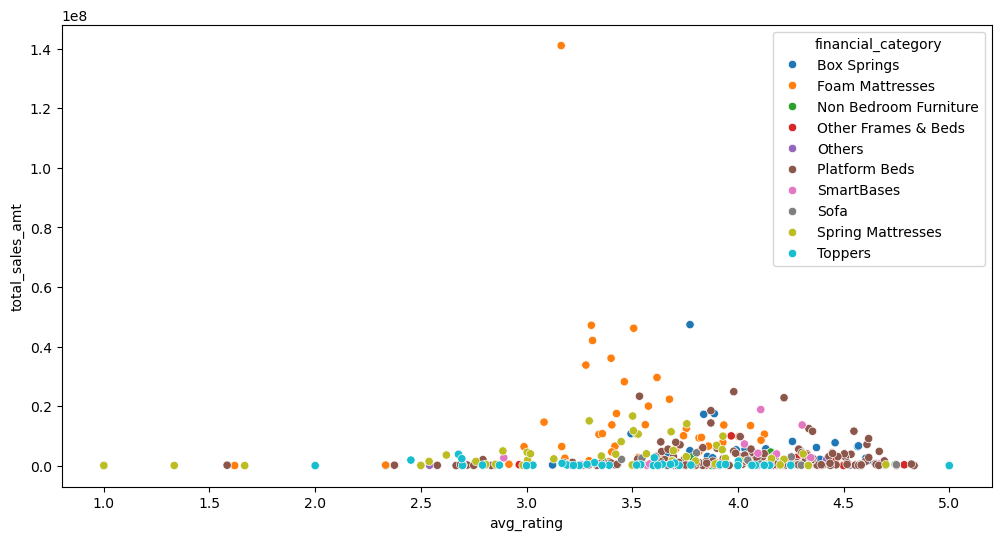

In [24]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=collection_summary, x='avg_rating', y='total_sales_amt', hue='financial_category')

## 3. Power BI용 dataset 

In [26]:
data1

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,category_type
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0,Non-Mattress
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0,Non-Mattress
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0,Non-Mattress
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0,Non-Mattress
5,202201,Box Springs,Victor 7.5in,4.750000,1.0,12.0,0.083333,NaN,NaN,NaN,NaN,57457.99,295.0,Non-Mattress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0,Non-Mattress
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0,Non-Mattress
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,Non-Mattress
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0,Non-Mattress


In [27]:
# 1. Category / Collection 별로 review 평균과 Sales 합 집계
summary_table = ( 
    data1.groupby(['financial_category','collection'])
    .agg(avg_rating=('written_avg_rating','mean'), total_review_cnt=('witten_all_cnt','sum'), total_sales_amt=('sales_amount','sum')).reset_index()
)

In [28]:
summary_table

,financial_category,collection,avg_rating,total_review_cnt,total_sales_amt
0,Box Springs,5in OOT Box Spring,3.123065,59.0,212189.73
1,Box Springs,9in OOT Box Spring,3.623485,59.0,250590.40
2,Box Springs,Adrianne,NaN,0.0,913.93
3,Box Springs,Annemarie,4.257992,594.0,8114259.42
4,Box Springs,Armita 5in,3.838275,836.0,17228795.75
...,...,...,...,...,...
670,Toppers,4in PRMF,NaN,0.0,30008.31
671,Toppers,4in PRMF w Cover,5.000000,2.0,0.00
672,Toppers,4in SWFT w WonderBox,2.791667,12.0,168236.40
673,Toppers,4in Swirl Gel,3.681159,50.0,442631.27


In [29]:
# 2. 평점 구간 생성: 0.1 ~ 5.1, 0.1 단위
bins = [round(i*0.1,1) for i in range(1,52)]
labels = [f'{round(bins[i],1)}' for i in range(len(bins)-1)]

In [30]:
# 3. 평점 구간에 컬럼 추가
data1['rating_bin'] = pd.cut(data1['written_avg_rating'], bins=bins, labels=labels, right=False)

In [31]:
# 4. 평점 구간별 매출 합계
pivot = (
    data1.groupby(['financial_category','collection','rating_bin'])['sales_amount'].sum().unstack(fill_value=0).reset_index()
)

C:\Users\최태욱\AppData\Local\Temp\ipykernel_14972\860249535.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data1.groupby(['financial_category','collection','rating_bin'])['sales_amount'].sum().unstack(fill_value=0).reset_index()


In [32]:
pivot

rating_bin,financial_category,collection,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0
0,Box Springs,0.75in Rejuvenator,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Box Springs,1.25in Swirl Copper,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Box Springs,1.5in Copper Convoluted,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Box Springs,1.5in GT MF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Box Springs,1.5in GTFT w WonderBox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6685,Toppers,Wood Metal Coffee Table,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6686,Toppers,Wood Squre Dining Table,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6687,Toppers,Yelena 14in,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6688,Toppers,Yelena 18in,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
# 5. 요약 테이블과 병합
rw_sales_with_bins = pd.merge(summary_table, pivot, on=['financial_category','collection'], how='left') 

In [34]:
#rw_sales_with_bins
rw_sales_with_bins.to_csv("collection_rating_sales_summary1.csv", index=False)

## 4. Collection별 리뷰-매출 분석

In [98]:
df = pd.read_csv("collection_rating_sales_summary1.csv")

In [99]:
df

,financial_category,collection,avg_rating,total_review_cnt,total_sales_amt,0.1,0.2,0.3,0.4,0.5,...,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0
0,Box Springs,5in OOT Box Spring,3.123065,59.0,212189.73,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
1,Box Springs,9in OOT Box Spring,3.623485,59.0,250590.40,0.0,0.0,0.0,0.0,0.0,...,0.00,88091.52,0.00,0.00,0.00,0.00,0.00,0.0,0.00,1154.88
2,Box Springs,Adrianne,NaN,0.0,913.93,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
3,Box Springs,Annemarie,4.257992,594.0,8114259.42,0.0,0.0,0.0,0.0,0.0,...,198483.17,1342570.90,820625.78,1523499.15,950383.33,732839.52,171346.42,0.0,125733.24,0.00
4,Box Springs,Armita 5in,3.838275,836.0,17228795.75,0.0,0.0,0.0,0.0,0.0,...,1264533.06,3749390.84,2737979.88,0.00,273970.72,0.00,0.00,0.0,0.00,56401.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,Toppers,4in PRMF,NaN,0.0,30008.31,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
671,Toppers,4in PRMF w Cover,5.000000,2.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
672,Toppers,4in SWFT w WonderBox,2.791667,12.0,168236.40,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,19391.08
673,Toppers,4in Swirl Gel,3.681159,50.0,442631.27,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,29093.26,16181.76,14665.80,0.00,0.00,0.0,0.00,100168.11


In [100]:
t_rw_counts = df.groupby('financial_category')['collection'].count()

In [101]:
t_rw_counts

financial_category
Box Springs               39
Foam Mattresses          103
Non Bedroom Furniture     82
Other Frames & Beds       40
Others                    20
Platform Beds            216
SmartBases                22
Sofa                      28
Spring Mattresses         75
Toppers                   50
Name: collection, dtype: int64

In [102]:
low_rw_counts = df[df['total_review_cnt'] < 10].groupby('financial_category')['collection'].count()

In [103]:
rw_cnt_df = pd.DataFrame({'total_collections': t_rw_counts, 'total_collections': low_rw_counts}).fillna(0)

In [104]:
rw_cnt_df

,total_collections
financial_category,
Box Springs,8
Foam Mattresses,46
Non Bedroom Furniture,68
Other Frames & Beds,25
Others,12
Platform Beds,90
SmartBases,10
Sofa,18
Spring Mattresses,35


In [105]:
#rw_cnt_df['percentage_less_10'] = (rw_cnt_df['collections_with_under10'] / rw_cnt_df['total_collections'])

In [106]:
rw_cnt_df

,total_collections
financial_category,
Box Springs,8
Foam Mattresses,46
Non Bedroom Furniture,68
Other Frames & Beds,25
Others,12
Platform Beds,90
SmartBases,10
Sofa,18
Spring Mattresses,35


In [107]:
df1 = df[df['total_review_cnt'] >= 10]

In [108]:
# 카테고리 목록 추출
categories = df1['financial_category'].unique()

In [109]:
categories

array(['Box Springs', 'Foam Mattresses', 'Non Bedroom Furniture',
       'Other Frames & Beds', 'Others', 'Platform Beds', 'SmartBases',
       'Sofa', 'Spring Mattresses', 'Toppers'], dtype=object)

In [110]:
max_y = 90000000

In [111]:
# 2. 평점 컬럼만 필터링하여 정렬
rating_columns = [col for col in df.columns if col.replace('.', '', 1).isdigit()]
sorted_ratings = sorted(rating_columns, key=lambda x: float(x))

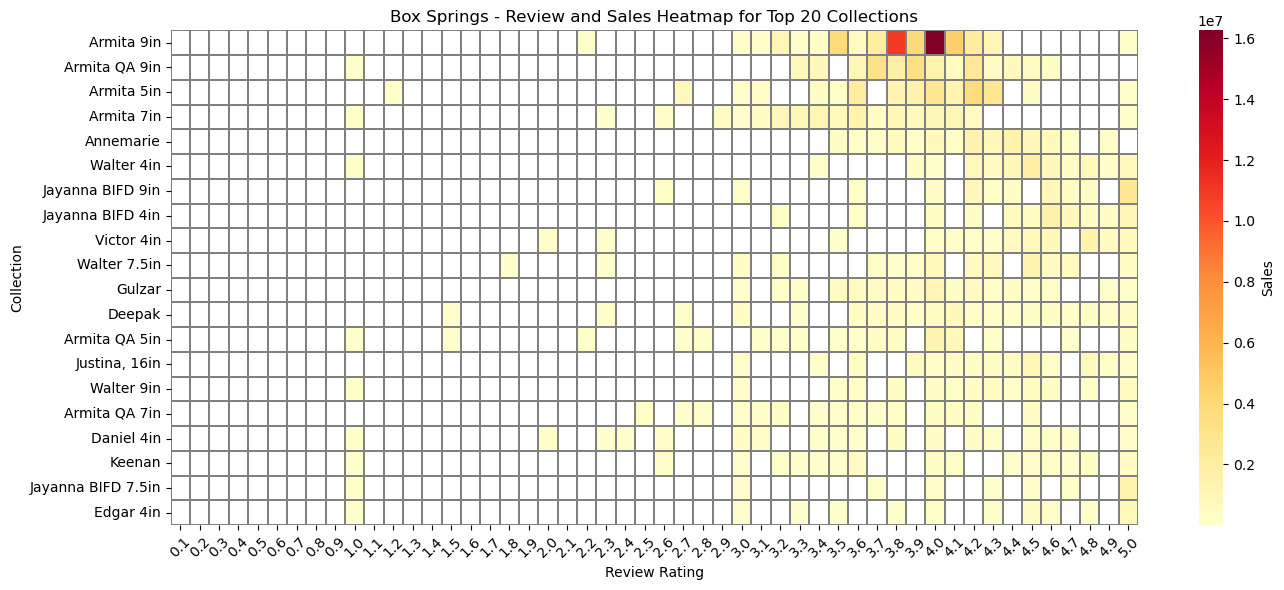

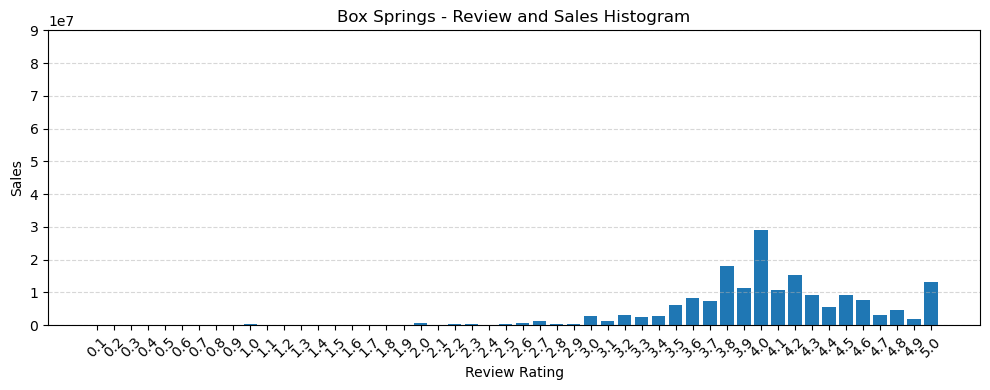

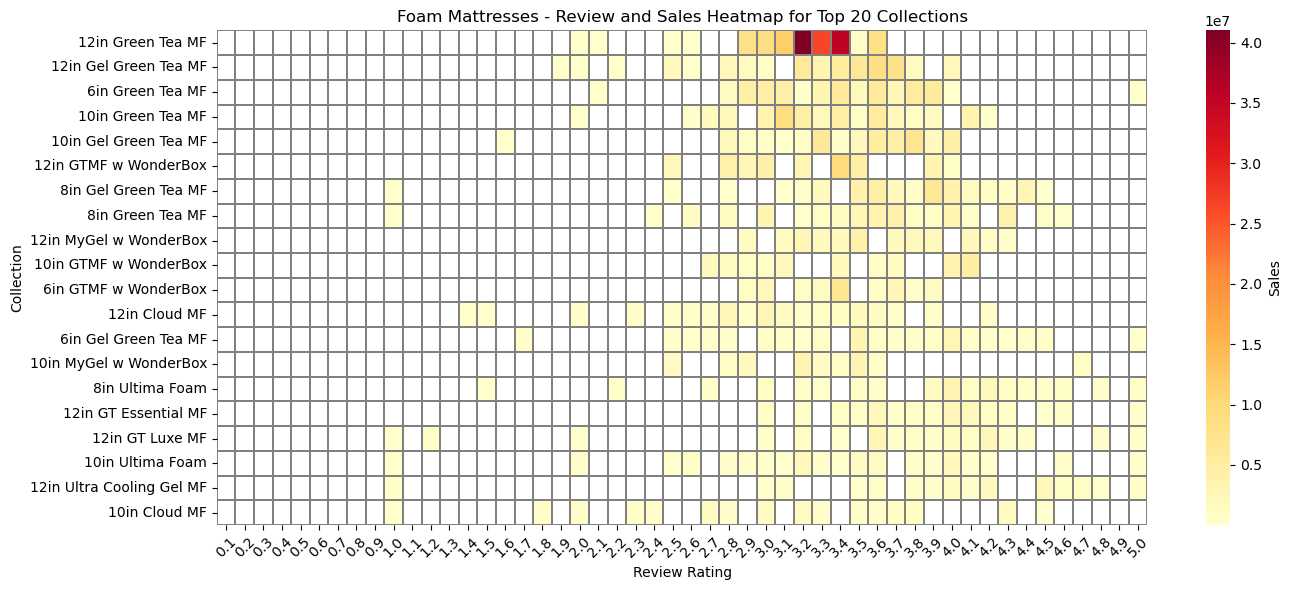

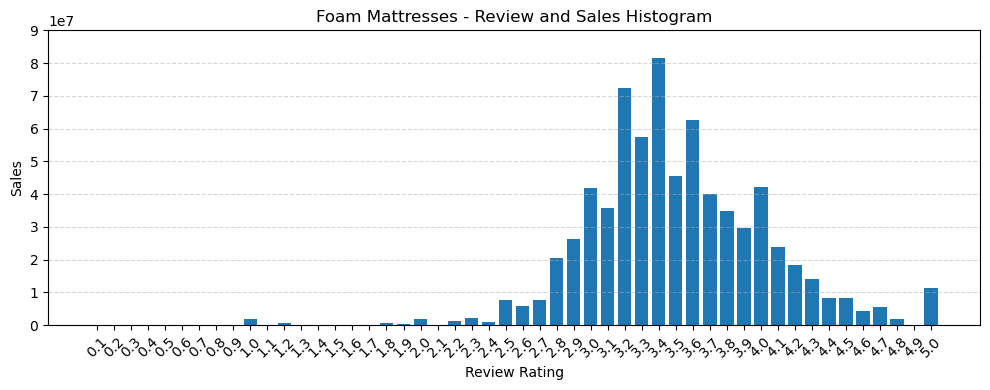

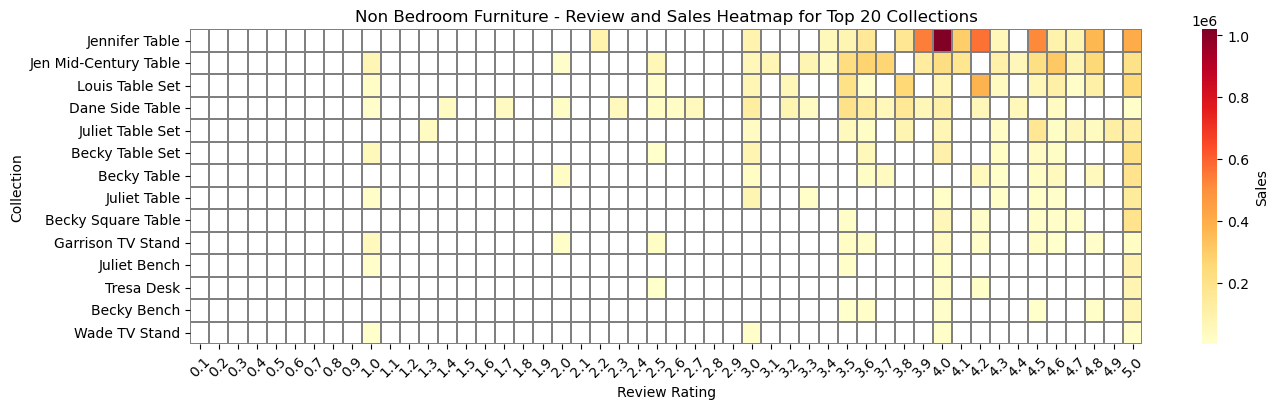

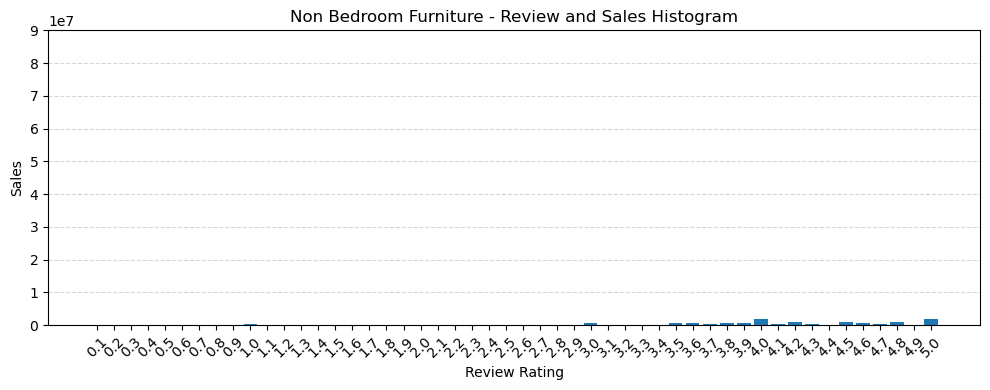

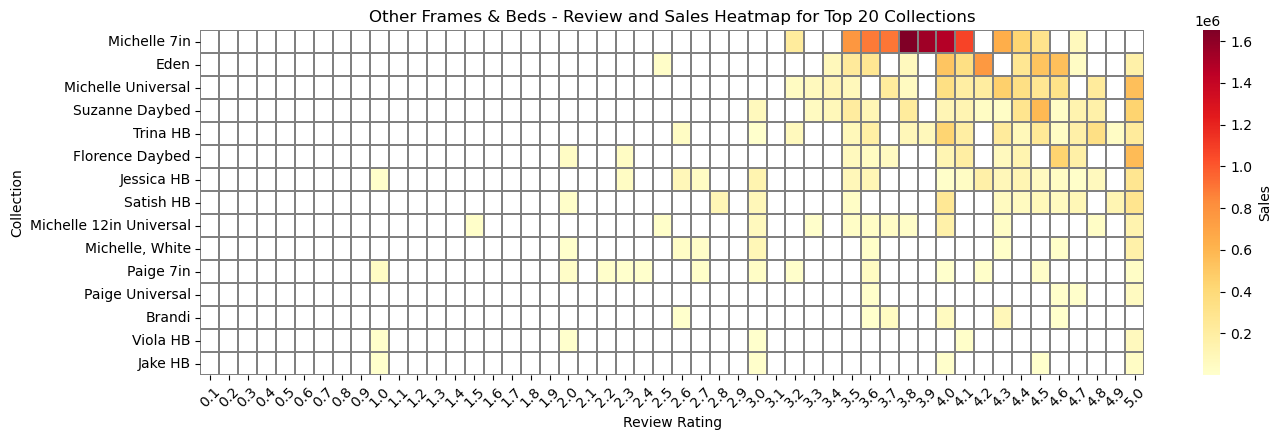

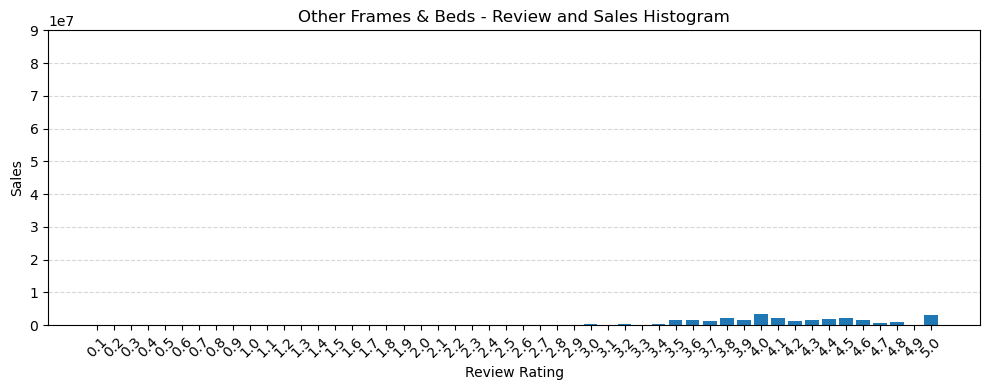

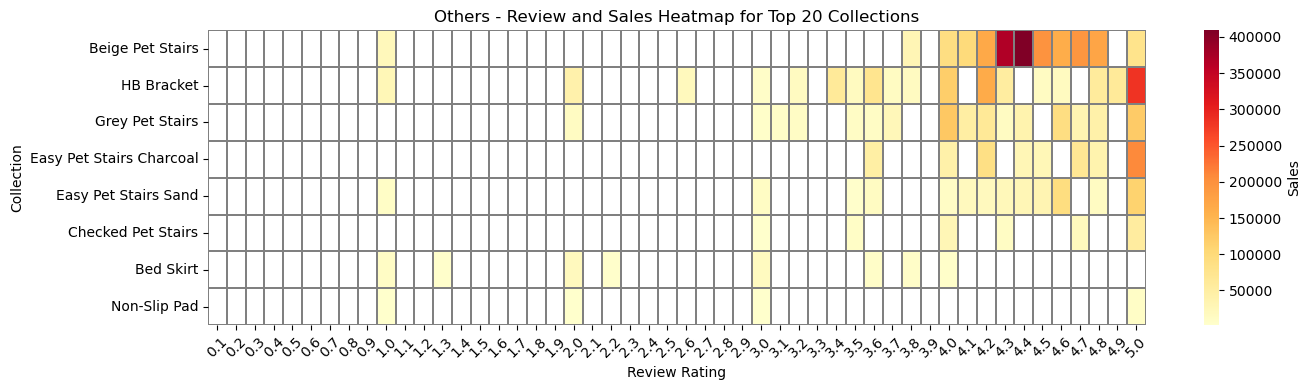

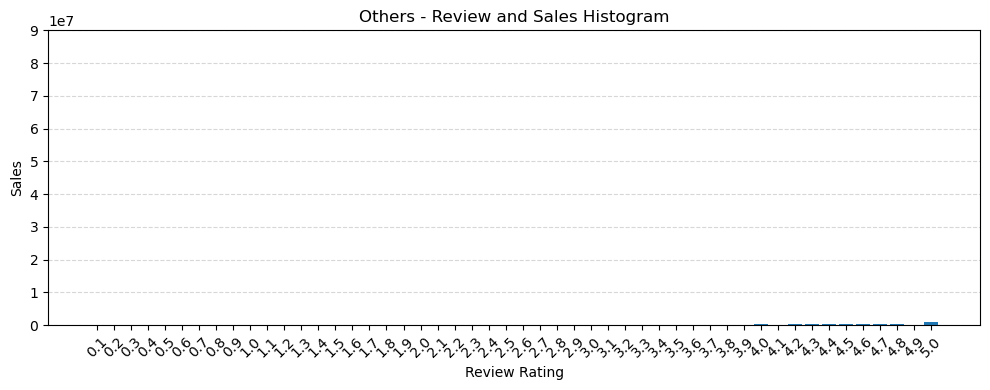

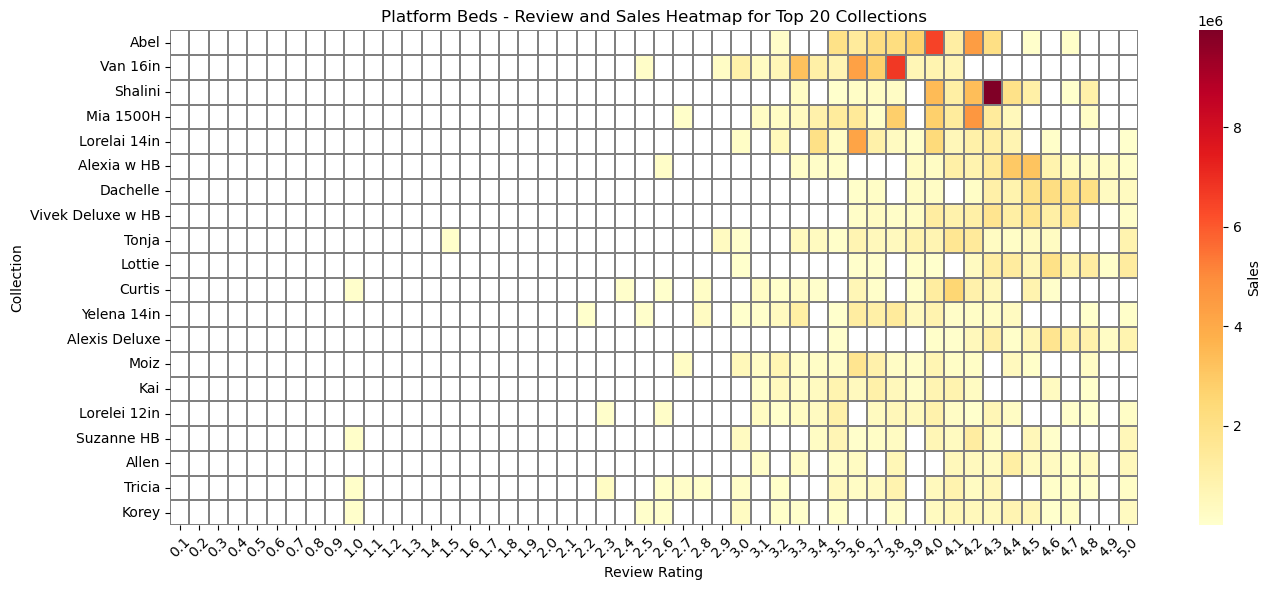

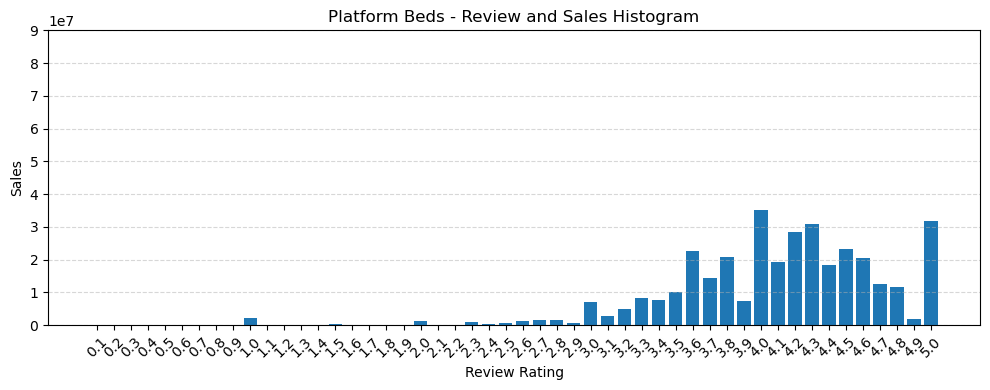

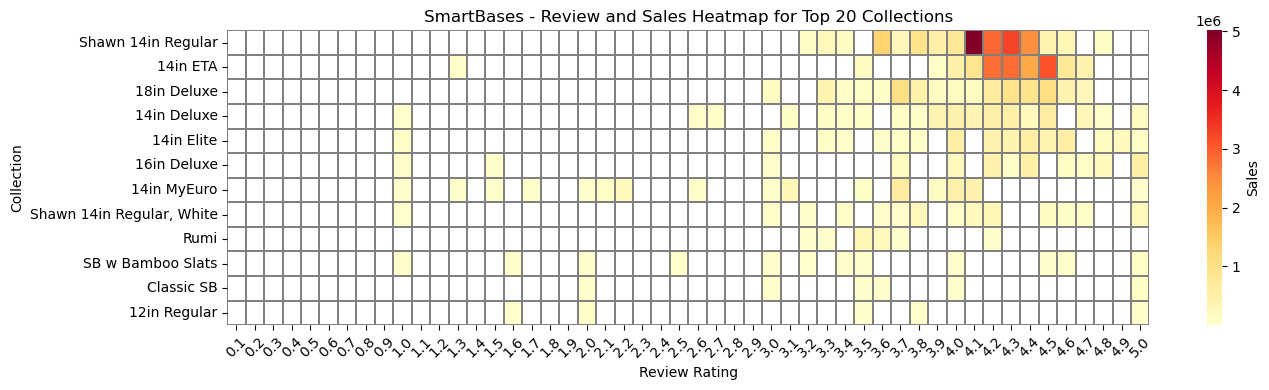

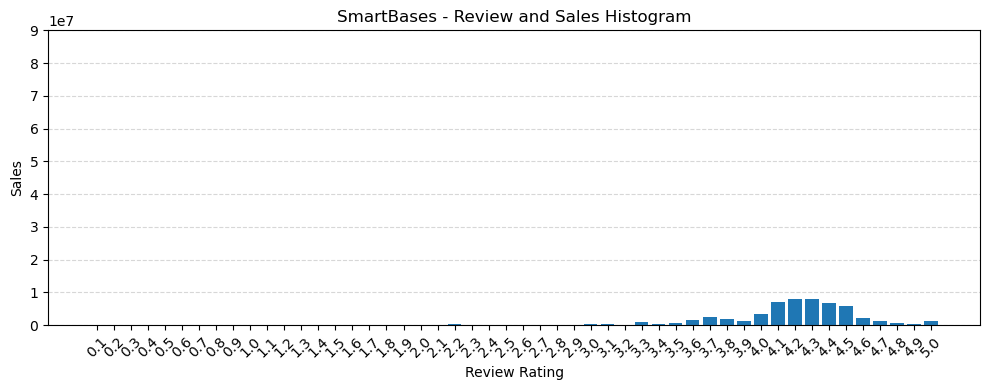

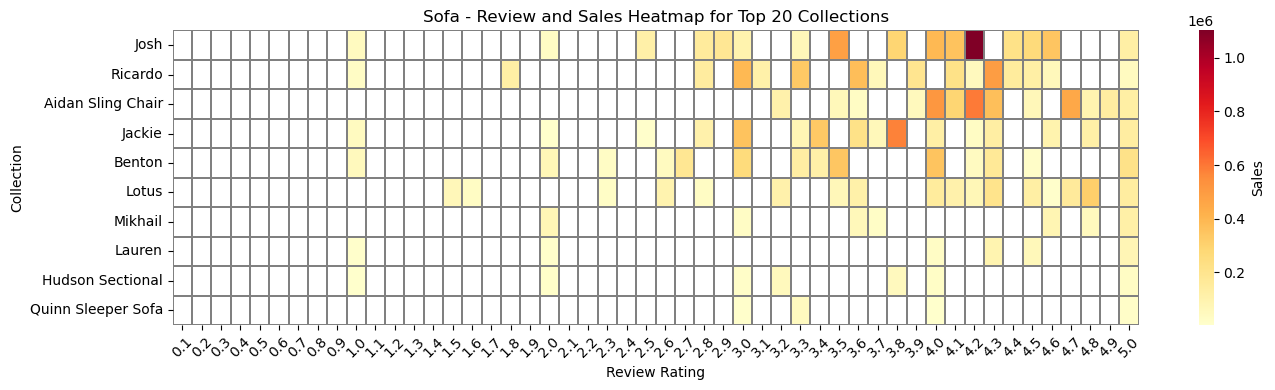

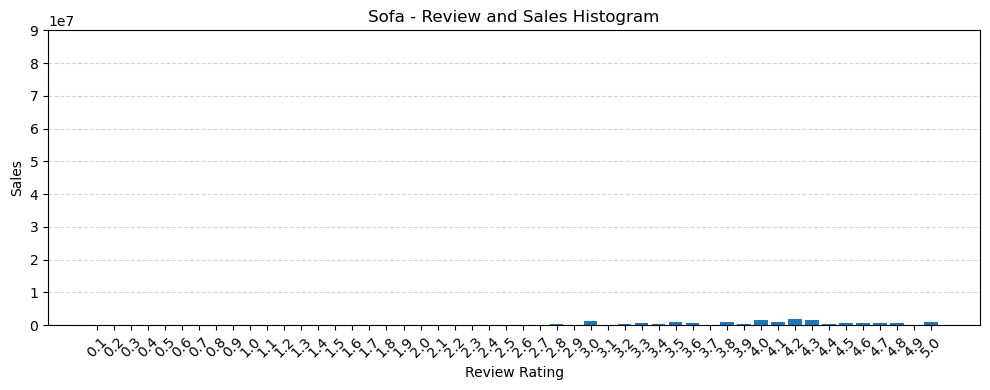

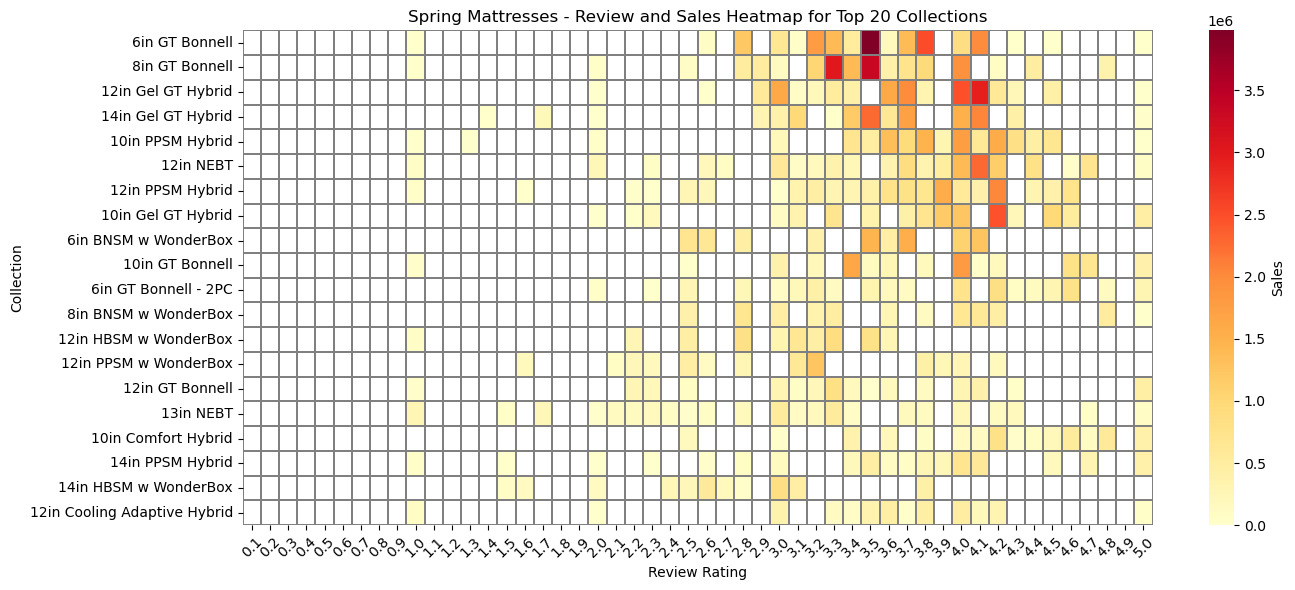

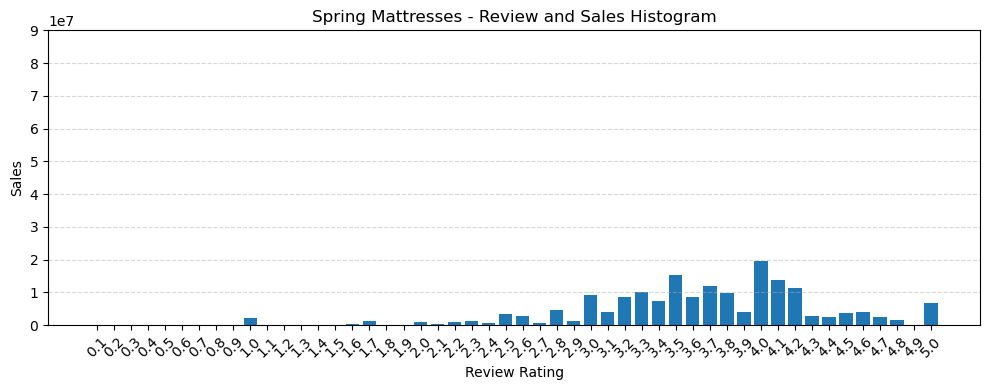

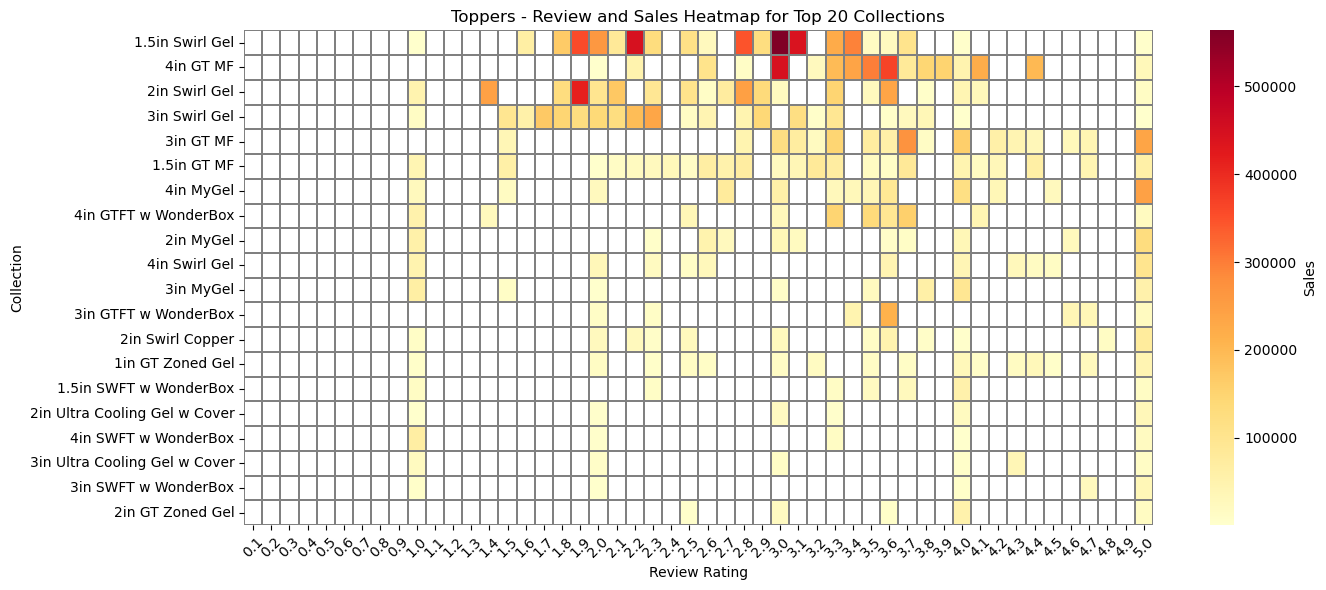

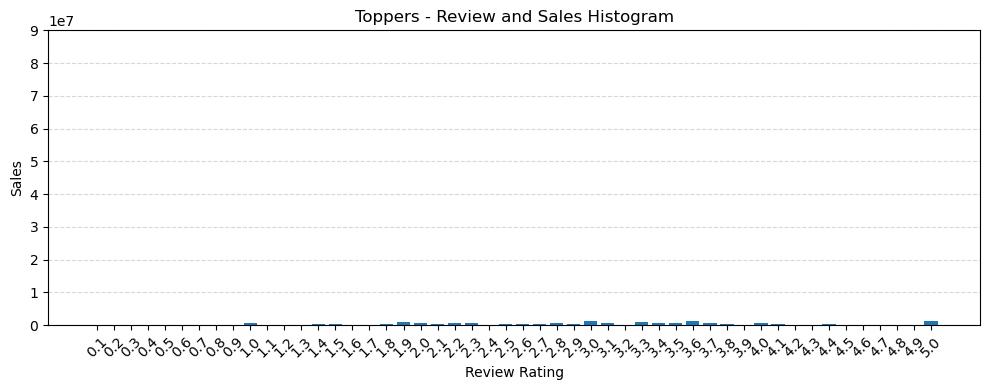

In [112]:
# 카테고리별로 히트맵 그리기
for category in categories: 
    subset = df1[df1['financial_category']==category]

    if subset.empty:
        continue

    # 매출 상위 20개 컬렉션
    top20 = subset.nlargest(20, 'total_sales_amt')

    # 히트맵 데이터 준비
    heatmap_data = top20.set_index('collection')[sorted_ratings]
    mask = heatmap_data == 0

    # 히트맵 시각화
    plt.figure(figsize=(14, max(4, len(heatmap_data)*0.3)))
    sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.3, linecolor='gray', mask=mask, cbar_kws={'label': 'Sales'})
    plt.title(f"{category} - Review and Sales Heatmap for Top 20 Collections")
    plt.xlabel("Review Rating")
    plt.ylabel("Collection")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 히스토그램
    category_total_sales = subset[sorted_ratings].sum()
    category_total_sales.index = category_total_sales.index.astype(float)

    plt.figure(figsize=(10,4))
    plt.bar(category_total_sales.index, category_total_sales.values, width=0.08)
    plt.title(f"{category} - Review and Sales Histogram")
    plt.xlabel("Review Rating")
    plt.ylabel("Sales")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(category_total_sales.index, rotation=45)
    plt.ylim(0, max_y)  # <-- Y축 스케일 고정
    plt.tight_layout()
    plt.show()
    